In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from math import nan
import pandas as pd
import yaml
import xesmf as xe
import dask
import socket
from pathlib import Path
import sys

sys.path.append("/glade/u/home/islas/python/CESM2_with_CMIP7_aer/utils/")
from reading_utils import *
from convert_units import *
from spread_emissions_func import *
from dask_utils import *

import os
import csv

import importlib
import convert_units as convert_units
importlib.reload(convert_units)
from convert_units import *


In [4]:
# Import molecular weights
from molecular_weights import *

### Species to plot

In [5]:
### Species to plot
species_to_plot = ['SO2','so4_a1','so4_a2','bc_a4','pom_a4','SOAG','so4_a1',
                   'SO2','so4_a1','bc_a4','pom_a4','SOAG']
emiss_type_to_plot = ['sfc','sfc','sfc','sfc','sfc','sfc','elev',
                      'sfc','sfc','sfc','sfc','sfc']
forcing_type_to_plot = ['anthro','anthro','anthro','anthro','anthro','anthro','anthro',
                        'bmb','bmb','bmb','bmb','bmb']

### Spin up dask cluster if dealing with elevated fields

In [6]:
if "elev" in emiss_type_to_plot:
    cluster = get_dask_cluster(4)
    print('starting dask cluster')

/glade/work/islas/conda-envs/islaenv26/lib/python3.10/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/work/islas/conda-envs/islaenv26/lib/python3.10/site-packages/dask_jobqueue/pbs.py:82: FutureWarning: project has been renamed to account as this kwarg was used wit -A option. You are still using it (please also check config files). If you did not set account yet, project will be respected for now, but it will be removed in a future release. If you already set account, project is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/work/islas/conda-envs/islaenv26/lib/python3.1

starting dask cluster


In [10]:
cluster

PBSCluster(64d6b148, 'tcp://10.18.206.75:42397', workers=4, threads=4, memory=111.76 GiB)

In [11]:
cmip6_pi_plot = []
cmip7_pi_plot = []
cmip6_hist_plot = []
cmip7_hist_plot = []
newdat_plot = []

for iplot in np.arange(0,len(species_to_plot),1):
    species = species_to_plot[iplot]
    emiss_type = emiss_type_to_plot[iplot]
    forcing_type = forcing_type_to_plot[iplot]

    # Read in the modified emissions file
    outpath="/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/"+forcing_type+"/"+emiss_type+"/CMIP7/"
    fout = outpath+"/"+species+"_"+forcing_type+"_"+emiss_type+"_cmip7_for_cesm2_negspread.nc"
    newdat = xr.open_dataset(fout)
    newdat = newdat.emiss
    
    # Read in the original emissions files
    cmip6_pi = read_emissions('../../emission_file_'+forcing_type+'_'+emiss_type+'_info.yml',species,'cmip6','piControl')
    cmip7_pi = read_emissions('../../emission_file_'+forcing_type+'_'+emiss_type+'_info.yml',species,'cmip7','piControl', dstgrid = 'f09')
    cmip6_hist = read_emissions('../../emission_file_'+forcing_type+'_'+emiss_type+'_info.yml',species,'cmip6','hist')
    cmip7_hist = read_emissions('../../emission_file_'+forcing_type+'_'+emiss_type+'_info.yml',species,'cmip7','hist', dstgrid='f09')

    # Sum over emissions type
    cmip6_pi = cmip6_pi.sum('emiss_type')
    cmip7_pi = cmip7_pi.sum('emiss_type')
    cmip6_hist = cmip6_hist.sum('emiss_type')
    cmip7_hist = cmip7_hist.sum('emiss_type')

    cmip6_hist = cmip6_hist.sel(time=slice("1850-01-01","2025-12-31"))
    cmip7_hist = cmip7_hist.sel(time=slice("1850-01-01","2025-12-31"))
    newdat = newdat.sel(time=slice("1850-01-01","2025-12-31"))

    if emiss_type == 'elev':
        cmip6_hist = cmip6_hist.chunk({'time':120})
        cmip7_hist = cmip7_hist.chunk({'time':120})
        newdat = newdat.chunk({'time':120})

    # Convert to Tg
    cmip6_pi_tg = convert_molecules_to_tg_specifywgt(cmip6_pi, mol_weights[species])
    cmip7_pi_tg = convert_molecules_to_tg_specifywgt(cmip7_pi, mol_weights[species])
    cmip6_hist_tg = convert_molecules_to_tg_specifywgt(cmip6_hist, mol_weights[species])
    cmip7_hist_tg = convert_molecules_to_tg_specifywgt(cmip7_hist, mol_weights[species])
    newdat_tg = convert_molecules_to_tg_specifywgt(newdat, mol_weights[species])

    # Calculate annual mean
    cmip6_pi_tg_am = cal.calcannualmean(cmip6_pi_tg)
    cmip7_pi_tg_am = cal.calcannualmean(cmip7_pi_tg)
    cmip6_hist_tg_am = cal.calcannualmean(cmip6_hist_tg)
    cmip7_hist_tg_am = cal.calcannualmean(cmip7_hist_tg)
    newdat_tg_am = cal.calcannualmean(newdat_tg)

    cmip6_pi_tg_am = cmip6_pi_tg_am.load()
    cmip7_pi_tg_am = cmip7_pi_tg_am.load()
    cmip6_hist_tg_am = cmip6_hist_tg_am.load()
    cmip7_hist_tg_am = cmip7_hist_tg_am.load()
    newdat_tg_am = newdat_tg_am.load()

    cmip6_pi_plot.append(cmip6_pi_tg_am)
    cmip7_pi_plot.append(cmip7_pi_tg_am)
    cmip6_hist_plot.append(cmip6_hist_tg_am)
    cmip7_hist_plot.append(cmip7_hist_tg_am)
    newdat_plot.append(newdat_tg_am)

/glade/p/cesmdata/cseg/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_SO2_anthro-ag-ship-res_surface_1750-2015_0.9x1.25_c20170616.nc
emiss_ag_sol_was
emiss_ship
emiss_res_tran
/glade/p/cesmdata/cseg/inputdata/atm/cam/chem/emis/CMIP6_emissions_1750_2015/emissions-cmip6_SO2_anthro-ene_surface_1750-2015_0.9x1.25_c20170616.nc
emiss_ene_ind
/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/REMAP/f09/SO2-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-04-18_gn_175001-202312_c20251030.nc
emiss
/glade/p/cesmdata/cseg/inputdata/atm/cam/chem/emis/emissions_ssp370/emissions-cmip6-ScenarioMIP_IAMC-AIM-ssp370-1-1_SO2_anthro-ag-ship-res_surface_mol_175001-210101_0.9x1.25_c20200924.nc
emiss_ag_sol_was
emiss_ship
emiss_res_tran
/glade/p/cesmdata/cseg/inputdata/atm/cam/chem/emis/emissions_ssp370/emissions-cmip6-ScenarioMIP_IAMC-AIM-ssp370-1-1_SO2_anthro-ene_surface_mol_175001-210101_0.9x1.25_c20190222.nc
emiss_ene_ind
/glade/campaign/cgd/cas/islas/p

/glade/work/islas/conda-envs/islaenv26/lib/python3.10/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 3.28 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/glade/work/islas/conda-envs/islaenv26/lib/python3.10/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 3.44 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


/glade/p/cesmdata/cseg/inputdata/atm/cam/chem/emis/emissions_ssp370-BB_smoothed/emissions-cmip6-ScenarioMIP_IAMC-AIM-ssp370-1-1_smoothed_SO2_bb_surface_mol_175001-210101_0.9x1.25_c20201016.nc
emiss_bb
/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/REMAP/f09/SO2_input4MIPs_emissions_CMIP_DRES-CMIP-BB4CMIP7-2-1_gn_175001-202312_c20251102.nc
emiss
/glade/p/cesmdata/cseg/inputdata/atm/cam/chem/emis/emissions_ssp370-BB_smoothed/emissions-cmip6-ScenarioMIP_IAMC-AIM-ssp370-1-1_smoothed_SO2_bb_surface_mol_175001-210101_0.9x1.25_c20201016.nc
emiss_bb
/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/REMAP/f09/SO2_input4MIPs_emissions_CMIP_DRES-CMIP-BB4CMIP7-2-1_gn_175001-202312_c20251102.nc
emiss
/glade/p/cesmdata/cseg/inputdata/atm/cam/chem/emis/emissions_ssp370-BB_smoothed/emissions-cmip6-ScenarioMIP_IAMC-AIM-ssp370-1-1_smoothed_so4_a1_bb_surface_mol_175001-210101_0.9x1.25_c20201016.nc
emiss_bb
/glade/campaign/cgd/cas/islas/python_sav

In [12]:
def plot_the_plot(fig, cmip6_pi, cmip6_hist, cmip7_pi, cmip7_hist, newdat, titlestr, x1, x2, y1, y2):
    ax = fig.add_axes([x1, y1, (x2-x1), (y2-y1)])
    ax.set_title(titlestr, fontsize=16)
    ax.set_ylabel('Emissions (Tg/s)', fontsize=14)
    ax.plot(cmip6_hist.year, cmip6_hist, color='royalblue', label='CMIP6')
    ax.plot([1850,2025],[cmip6_pi, cmip6_pi], color='royalblue', linestyle='dashed', label='CMIP6 piControl')
    ax.plot(cmip7_hist.year, cmip7_hist, color='red', label='CMIP7')
    ax.plot([1850,2025],[cmip7_pi, cmip7_pi], color='red', linestyle='dotted', label='CMIP7 piControl')
    ax.plot(newdat.year, newdat, color='orange', linestyle='dashed', linewidth=2, label='CMIP7 adjusted')  
    ax.legend()
    return ax

In [13]:
x1=[0.0,0.31,0.62,0.93,
    0.0,0.31,0.62,0.93,
    0.0,0.31,0.62,0.93,
    0.0,0.31,0.62,0.93]
x2=[0.26,0.57,0.88,1.19,
    0.26,0.57,0.88,1.19,
    0.26,0.57,0.88,1.19,
    0.26,0.57,0.88,1.19]
y1=[0.8,0.8,0.8,0.8,
    0.59,0.59,0.59,0.59,
    0.38,0.38,0.38,0.38,
    0.17,0.17,0.17,0.17]
y2=[0.97,0.97,0.97,0.97,
    0.76,0.76,0.76,0.76,
    0.55,0.55,0.55,0.55,
    0.34,0.34,0.34,0.34]

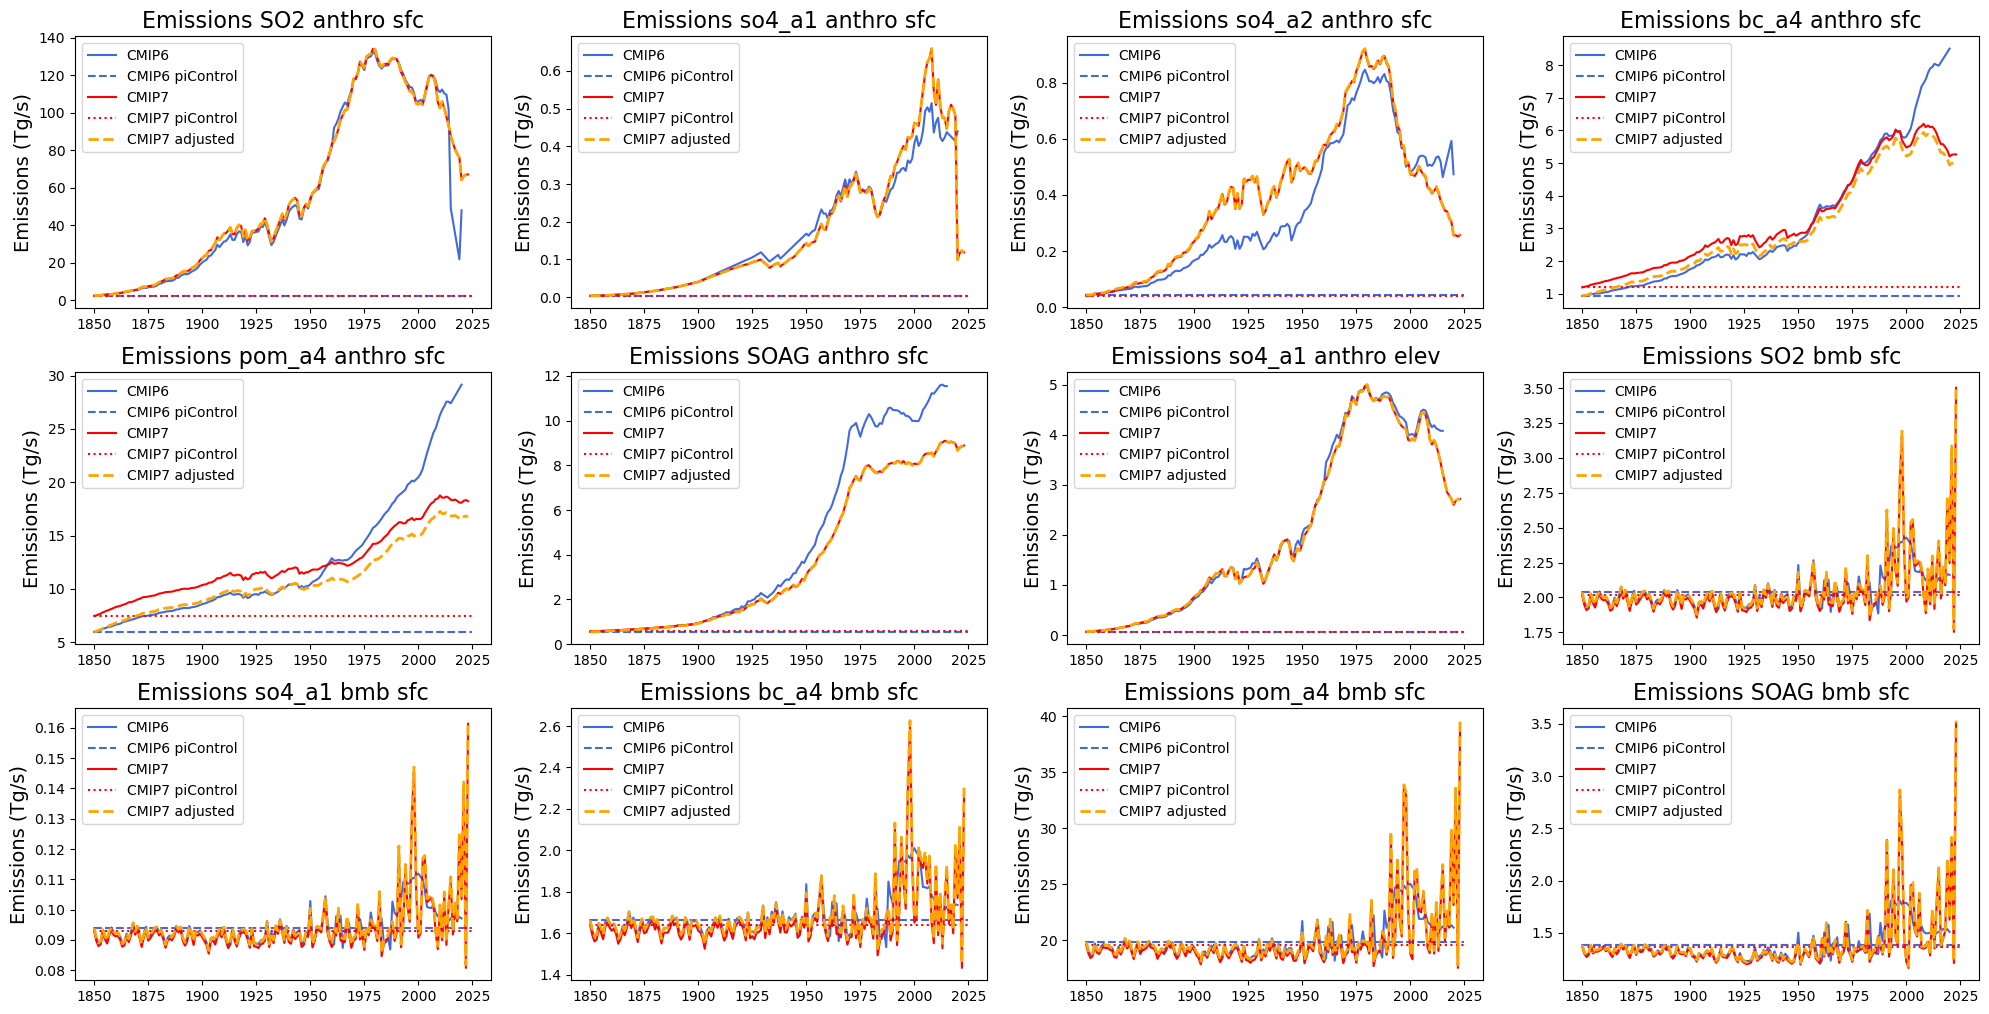

In [14]:
fig = plt.figure(figsize=(16,16))

for iplot in np.arange(0,len(cmip6_pi_plot),1):
    ax = plot_the_plot(fig, cmip6_pi_plot[iplot], cmip6_hist_plot[iplot], cmip7_pi_plot[iplot], cmip7_hist_plot[iplot], newdat_plot[iplot],
                      'Emissions '+species_to_plot[iplot]+' '+forcing_type_to_plot[iplot]+' '+emiss_type_to_plot[iplot],
                      x1[iplot],x2[iplot],y1[iplot],y2[iplot])
    

In [15]:
def plot_the_difference(fig, cmip6_pi, cmip6_hist, cmip7_pi, cmip7_hist, newdat, titlestr, x1, x2, y1, y2):
    ax = fig.add_axes([x1, y1, (x2-x1), (y2-y1)])
    ax.set_title(titlestr, fontsize=16)
    ax.set_ylabel('Emissions (Tg/s)', fontsize=14)
    ax.plot(newdat.year, newdat - cmip7_hist, color='black', linewidth=2, label='CMIP7 adjusted $-$ CMIP7')
    ax.plot(newdat.year, newdat.year*0 + (cmip6_pi - cmip7_pi).isel(year=0), color='gray', linestyle='dashed', 
            linewidth=2, label='CMIP6 piControl $-$ CMIP7 piControl')
    ax.legend()
    return ax

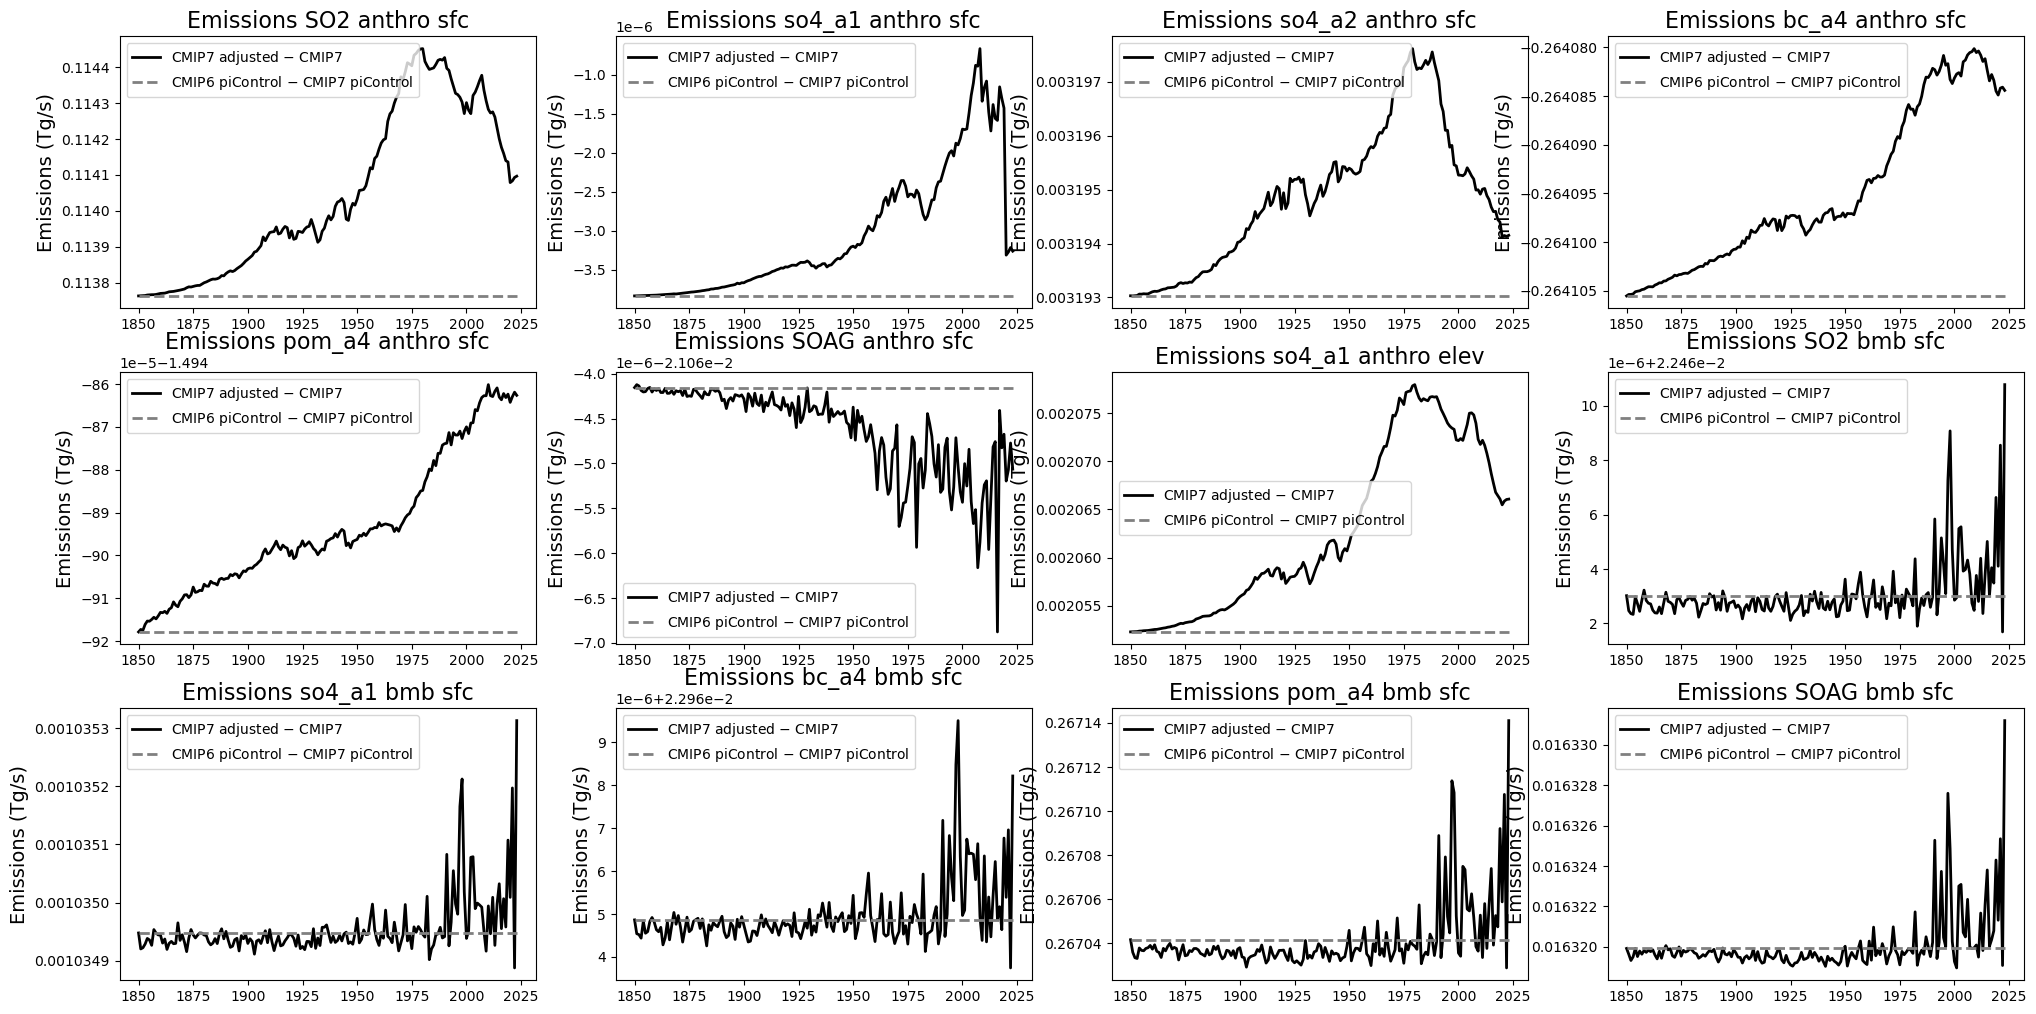

In [16]:
fig = plt.figure(figsize=(16,16))

for iplot in np.arange(0,len(cmip6_pi_plot),1):
    ax = plot_the_difference(fig, cmip6_pi_plot[iplot], cmip6_hist_plot[iplot], cmip7_pi_plot[iplot], cmip7_hist_plot[iplot], newdat_plot[iplot],
                      'Emissions '+species_to_plot[iplot]+' '+forcing_type_to_plot[iplot]+' '+emiss_type_to_plot[iplot],
                      x1[iplot],x2[iplot],y1[iplot],y2[iplot])
    